# Setup

In [1]:
%%capture
# Catch warnings
import warnings

# Maths functions
from numpy import (sort, mean, std, argmax, arange)

# Data manipulation
import pandas as pd
import numpy as np

# Statistical analysis
from scipy.stats import f_oneway

# Data visualization 
import matplotlib as mp
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.style as style
import matplotlib.font_manager as font_manager
style.use('ggplot')
%matplotlib inline

import seaborn as sns
sns.set_context('talk')

# Model development
import sklearn
from sklearn.preprocessing import (StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model selection and evaluation
from sklearn.model_selection import (train_test_split, cross_val_score, RepeatedStratifiedKFold) 
import optuna
from yellowbrick.classifier import (ConfusionMatrix, DiscriminationThreshold)
from sklego.meta import Thresholder
from sklearn.metrics import (make_scorer, accuracy_score,  roc_auc_score,roc_curve, 
                             precision_recall_curve, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_score, recall_score, fbeta_score) 

# Feature Importance
import shap

# Save model
import joblib

# Set notebook options
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', 100)
pd.set_option("display.max_rows", 10000)
pd.set_option("display.float_format", lambda x: '%.2f' % x)

# Pretty display of multiple functions in a cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Set random state
RANDOM_STATE = 2021

# Analysis
## The Problem Size

C:\Users\yvett\AppData\Local\Temp\ipykernel_57044\3724244391.py:9: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax1 = plt.subplot(gs[0])


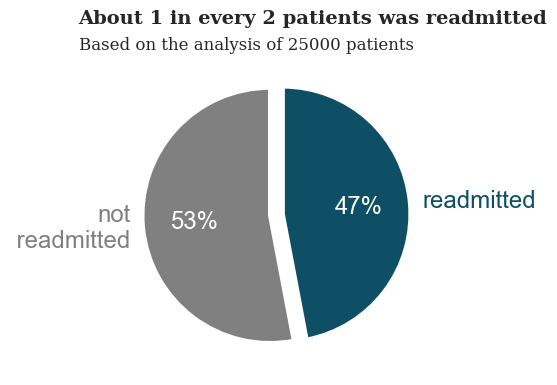

In [2]:
df = pd.read_csv('../data/raw/hospital_readmissions.csv')

df['counter'] = 1
readmission_prop = df[['readmitted', 'counter']].groupby(['readmitted']).count()/df.shape[0] 

fig = plt.subplots(figsize=(10, 4))
gs= gridspec.GridSpec(1,2, width_ratios=[2,2])

ax1 = plt.subplot(gs[0])

patches, texts, pcts = ax1.pie(readmission_prop['counter'],
        labels = ['not\n readmitted', 'readmitted'],
        autopct='%0.0f%%',
        colors = ('gray', '#0e4f66'),
    wedgeprops={'linewidth': 3.0, 'edgecolor': 'white'},
    textprops={'size': 'x-large'},
    startangle=90,
    explode=(0, 0.1))

for i, patch in enumerate(patches):
  texts[i].set_color(patch.get_facecolor())
plt.setp(pcts, color='white')
plt.setp(texts, fontweight=50)

ax1.text(-1.5, 1.5, 'About 1 in every 2 patients was readmitted', fontsize=14, fontweight='bold', fontfamily='serif')
ax1.text(-1.5, 1.30,'Based on the analysis of 25000 patients',fontfamily='serif',fontsize=12)

plt.tight_layout()
plt.savefig('../reports/figures/target distribution.png', bbox_inches='tight')
plt.show();

## Key Insight 1

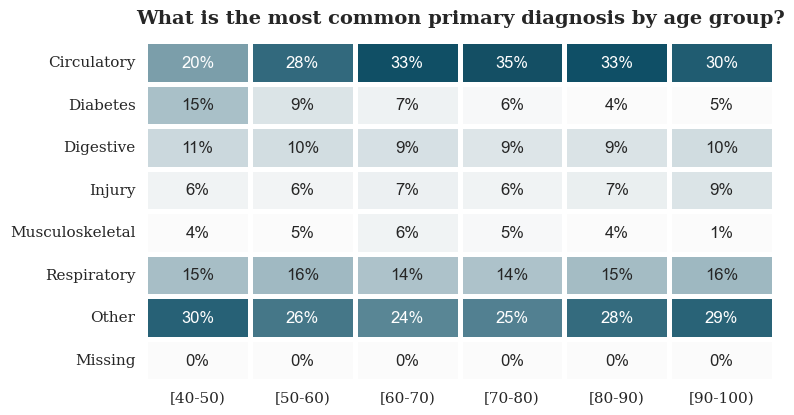

In [3]:
df['age_o'] = pd.Categorical(df['age'], ['[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'])

df['diag_1_o'] = pd.Categorical(df['diag_1'], ['Circulatory', 'Diabetes', 'Digestive', 'Injury', 'Musculoskeletal', 'Respiratory', 'Other', 'Missing'])

df_heatmap1 = pd.crosstab(df['age_o'],df['diag_1_o'],normalize = "index").T

colors = ["#fbfbfb", "#0e4f66", "#4b4b4c"]
colormap = mp.colors.LinearSegmentedColormap.from_list("", colors)

fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(df_heatmap1,cmap=colormap,square=False, linewidth=2.5,cbar=False,
            annot=True,fmt='1.0%',vmax=.6,vmin=0.05,ax=ax,annot_kws={"fontsize":12})

ax.spines['top'].set_visible(False)


fig.text(0.18, 1, 'What is the most common primary diagnosis by age group?', fontweight='bold', fontfamily='serif', fontsize=14)

ax.set_yticklabels(ax.get_yticklabels(), fontfamily='serif', rotation = 0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontfamily='serif', rotation=0, fontsize=11)

ax.set_ylabel('')    
ax.set_xlabel('')
ax.tick_params(axis=u'both', which=u'both',length=0)

plt.tight_layout()
plt.savefig('../reports/figures/primary diagnosis by age group.png', bbox_inches='tight')
plt.show();

- "Circulatory" diagnosis is the most common primary diagnosis of patients aged 50 years and above.
- Patients aged under 50 years, were diagnosed with "Other" as the most common primary diagnosis.

## Key Insight 2
### A diagnosis of Diabetes was not found to influence readmission rates

A patient could never be diagnosed with diabetes or could be diagnosed with diabetes up to at most three times.

A hypothesis test to investigate the effect of diabetes diagnosis on hospital readmissions at a significance level of 0.05:

- Null hypothesis (H0) : A diagnosis of diabetes is not correlated with hospital readmission
- Alternative hypothesis (H1) : A diagnosis of diabetes is correlated with hospital readmission

In [4]:
num_cols = list(df.select_dtypes(include=['float64', 'int64']).columns)

def check_category_numerical_correlation(_df, cat_col, num_cols):
    '''Anova hypothesis testing assumptions:
        
    Null hypothesis(H0): The variables are not correlated with each other
    P-value: The probability of Null hypothesis being true
    Accept Null hypothesis if P-value>0.05. Means variables are NOT correlated
    Reject Null hypothesis if P-value<0.05. Means variables are correlated
   
    '''

    col_list = []
    anova_pval_list = []
    
    for col in num_cols:
        category_grp_list=_df.groupby(cat_col)[col].apply(list)
    
        anova_results = f_oneway(*category_grp_list)
        anova_pval_list.append(anova_results[1])
        col_list.append(col)
        
    _df_results = pd.DataFrame(list(zip(col_list, anova_pval_list)), columns=['Variable', 'P-value'])   
    df_final = _df_results.sort_values(['P-value']).reset_index(drop=True)
    
    return df_final

isY = lambda x:int(x=='Diabetes')

countNumberOfDiabetesDiag = lambda row: isY(row['diag_1']) + isY(row['diag_2']) + isY(row['diag_3'])

df['n_diabetes_diag'] = df.apply(countNumberOfDiabetesDiag,axis=1)

num_cols = ['n_diabetes_diag',
            'time_in_hospital',
 'n_lab_procedures',
 'n_procedures',
 'n_medications',
 'n_outpatient',
 'n_inpatient',
 'n_emergency']

colors = ["lightgray","lightgray","#0e4f66"]
colormap = mp.colors.LinearSegmentedColormap.from_list("", colors)

num_corr_check = check_category_numerical_correlation(df, 'readmitted', num_cols)
num_corr_check.style.set_properties(**{'text-align': 'center'}).format({'P-value': "{:.2f}"}).background_gradient(cmap=colormap)

,Variable,P-value
0,n_inpatient,0.00
1,n_outpatient,0.00
2,n_emergency,0.00
3,n_procedures,0.00
4,time_in_hospital,0.00
5,n_medications,0.00
6,n_lab_procedures,0.00
7,n_diabetes_diag,0.53


- The p-value (0.53) from the hypothesis test is greater than the significance level of 0.05. We accept the Null Hypothesis that diagnosis of diabetes is not correlated with hospital readmission.

## Feature Distribution

In [5]:
df.describe()

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,counter,n_diabetes_diag
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,4.45,43.24,1.35,16.25,0.37,0.62,0.19,1.00,0.36
std,3.00,19.82,1.72,8.06,1.20,1.18,0.89,0.00,0.49
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00
25%,2.00,31.00,0.00,11.00,0.00,0.00,0.00,1.00,0.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,1.00,0.00
75%,6.00,57.00,2.00,20.00,0.00,1.00,0.00,1.00,1.00
max,14.00,113.00,6.00,79.00,33.00,15.00,64.00,1.00,3.00


In [6]:
cols_object=[(col, df[col].unique()) for col in df.columns if df[col].dtype=='object']
pd.DataFrame(cols_object)

,0,1
0,age,"[[70-80), [50-60), [60-70), [40-50), [80-90), [90-100)]"
1,medical_specialty,"[Missing, Other, InternalMedicine, Family/GeneralPractice, Cardiology, Surgery, Emergency/Trauma]"
2,diag_1,"[Circulatory, Other, Injury, Digestive, Respiratory, Diabetes, Musculoskeletal, Missing]"
3,diag_2,"[Respiratory, Other, Circulatory, Injury, Diabetes, Digestive, Musculoskeletal, Missing]"
4,diag_3,"[Other, Circulatory, Diabetes, Respiratory, Injury, Musculoskeletal, Digestive, Missing]"
5,glucose_test,"[no, normal, high]"
6,A1Ctest,"[no, normal, high]"
7,change,"[no, yes]"
8,diabetes_med,"[yes, no]"
9,readmitted,"[no, yes]"


## Modeling Methodology
### Pre-Modeling
#### 1. Metric Definition

Given the classes were slightly balanced, the "Accuracy" metric was used to evaluate the models developed.

In [7]:
# Calculate accuracy score
def acc(y_true, y_pred):
    return accuracy_score(y_true, y_pred)
 
# Evaluate model
def evaluate_model(X, y, model):
    # define evaluation procedure
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    # define the model evaluation the metric
    metric = make_scorer(acc)
    # evaluate model
    scores = cross_val_score(model, X, y, scoring=metric, cv=cv, n_jobs=-1)
    return scores

#### 2. Data Preprocessing

In [8]:
# Feature selection
input_features = ['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med']
#, 'n_diabetes_diag'
target = ['readmitted']

# Target
y = df[target]

# Label encode the target variable to have the classes 0 and 1
y = LabelEncoder().fit_transform(y.values.ravel())

# Input features
df = df.drop(['counter', 'age_o', 'diag_1_o'], axis=1)
X = df[input_features]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=RANDOM_STATE)

# Numerical features indices
num_ix = [1, 2, 3, 4, 5, 6, 7]

# preprocess features
ordinal_features=['age', 'glucose_test', 'A1Ctest']
ordinal_orders=[ 
    #age 
['[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'], 
    #glucose_test 
['high', 'normal', 'no'], 
    #A1Ctest
['high', 'normal', 'no']
]
ordinal_transformer = OrdinalEncoder(categories= ordinal_orders, handle_unknown='use_encoded_value', unknown_value=-1)

nominal_features = ['medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'change', 'diabetes_med']
nominal_transformer = OneHotEncoder(handle_unknown='ignore')

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', ordinal_transformer, ordinal_features),
        ('nominal', nominal_transformer, nominal_features),
    ], remainder='passthrough'
) 

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), num_ix), 
        ('ordinal', ordinal_transformer, ordinal_features),
        ('nominal', nominal_transformer, nominal_features),
    ], remainder='passthrough'
) 
#- An additional feature was derived, the **number of diabetes diagnoses**

- The numerical features were standardized
- The categorical features were preprocessed accordingly based on whether they were ordinal or nominal
- The modeling was done with 17 input features

### Model Selection and Optimization
#### 1. Baseline Model

In [9]:
# Define the reference model
baseline_model = DummyClassifier(strategy='constant', constant=1)

# Define pipeline
pipe0 = sklearn.pipeline.Pipeline(steps=[('p', baseline_preprocessor), ('m', baseline_model)])

# Evaluate the model
scores = evaluate_model(X, y, pipe0)

# Summarize performance
print('The mean accuracy score of the baseline model (a dummy classifier) is %.3f ± %.3f' % (np.mean(scores), std(scores)))

The mean accuracy score of the baseline model (a dummy classifier) is 0.470 ± 0.000


#### 2. Evaluate/ Spot-Check ML Algorithms

##### without preprocessing numerical variables

>Logistic 
Regression 0.612 ± 0.009
>K-Nearest 
Neighbour 0.552 ± 0.006
>Random 
Forest 0.605 ± 0.009


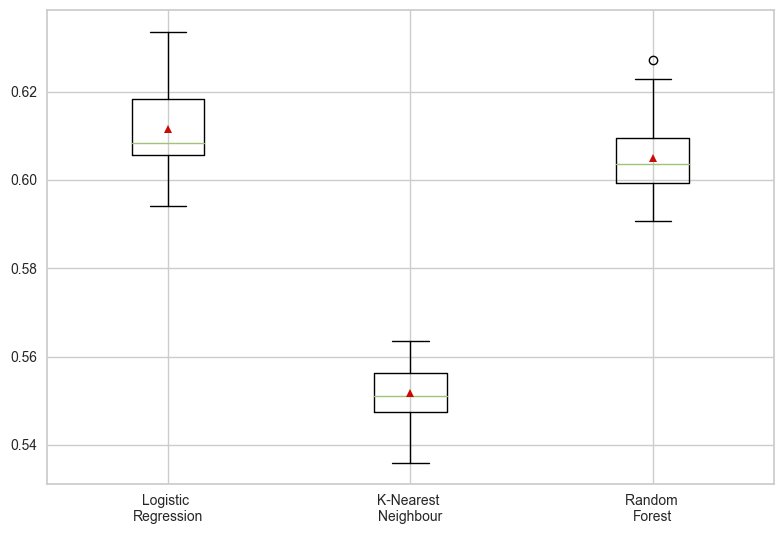

In [10]:
# define models to test
def get_models():
    models, names = list(), list()
    
    #linear models
    # Logistic' 
    models.append(LogisticRegression(solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE))
    names.append('Logistic \nRegression')

    #non-linear models
    # KNN
    models.append(KNeighborsClassifier())
    names.append('K-Nearest \nNeighbour')
    
    #ensemble models
    # RF
    models.append(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
    names.append('Random \nForest')
    return models, names

# define models
models, names = get_models()
results = list()

# evaluate each model
for i in range(len(models)):
    # wrap the model i a pipeline
    pipeline = Pipeline(steps=[('p', baseline_preprocessor),('m',models[i])])
    
    # evaluate the model and store results
    scores = evaluate_model(X, y, pipeline)
    results.append(scores)
    
    # summarize and store
    print('>%s %.3f ± %.3f' % (names[i], np.mean(scores), std(scores)))
    
# plot the results
plt.boxplot(results, labels=names, showmeans=True)
plt.tight_layout()
plt.savefig('../reports/figures/model performance without preprocessing.png', bbox_inches='tight')
plt.show();

##### with preprocessing numerical variables

>Logistic 
Regression 0.612 ± 0.009
>K-Nearest 
Neighbour 0.568 ± 0.009
>Random 
Forest 0.605 ± 0.009


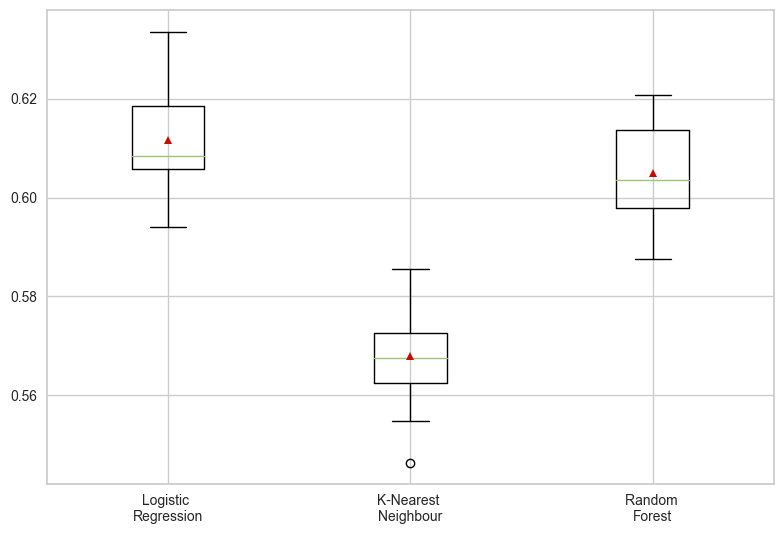

In [11]:
# define models to test
def get_models():
    models, names = list(), list()
    
    #linear models
    # Logistic' 
    models.append(LogisticRegression(solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE))
    names.append('Logistic \nRegression')

    #non-linear models
    # KNN
    models.append(KNeighborsClassifier())
    names.append('K-Nearest \nNeighbour')
    
    #ensemble models
    # RF
    models.append(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
    names.append('Random \nForest')
    return models, names


# define models
models, names = get_models()
results = list()

# evaluate each model
for i in range(len(models)):
    
    # standardize numerical
    ct = ColumnTransformer([('num', StandardScaler(), num_ix),        
                            ('ord', ordinal_transformer, ordinal_features),
                            ('nom', nominal_transformer, nominal_features),
    ], remainder='passthrough')
    
    # wrap the model i a pipeline
    pipeline = Pipeline(steps=[('t',ct),('m',models[i])])
    
    # evaluate the model and store results
    scores = evaluate_model(X, y, pipeline)
    results.append(scores)
    
    # summarize and store
    print('>%s %.3f ± %.3f' % (names[i], np.mean(scores), std(scores)))
# plot the results
plt.boxplot(results, labels=names, showmeans=True)
plt.tight_layout()
plt.savefig('../reports/figures/model performance with preprocessing.png', bbox_inches='tight')
plt.show();

#### 3. Hyperparameter Tuning of "Best" Model

In [12]:
# Define grid search
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)
metric = make_scorer(acc)

def objective(trial):
    # Suggest hyperparameters
    solver = trial.suggest_categorical("solver", ["newton-cg", "liblinear"])
    penalty = trial.suggest_categorical("penalty", ["l2"])
    C = trial.suggest_float("C", 0.01, 100, log=True)

    # Define model + pipeline
    model = LogisticRegression(
        solver=solver,
        penalty=penalty,
        C=C,
        random_state=RANDOM_STATE,
        max_iter=1000
    )
    
    pipe = Pipeline([
        ("p", preprocessor),
        ("m", model)
    ])

    # Cross-validated score
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=metric,
        n_jobs=-1
    )

    return scores.mean()
  
# Create and run study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)  # increase trials if needed

# Best results
print(f"Best accuracy: {study.best_value:.4f}")
print(f"Best parameters: {study.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-12 13:29:38,593] Trial 0 finished with value: 0.6134925373134327 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 3.9298061085552924}. Best is trial 0 with value: 0.6134925373134327.
[I 2026-09-12 13:29:46,809] Trial 1 finished with value: 0.6135124378109452 and parameters: {'solver': 'newton-cg', 'penalty': 'l2', 'C': 3.2478004979704713}. Best is trial 1 with value: 0.6135124378109452.
[I 2026-09-12 13:29:49,192] Trial 2 finished with value: 0.6135522388059702 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.1857605074257645}. Best is trial 2 with value: 0.6135522388059702.
[I 2026-09-12 13:29:56,823] Trial 3 finished with value: 0.6135721393034825 and parameters: {'solver': 'newton-cg', 'penalty': 'l2', 'C': 0.6976965420699692}. Best is trial 3 with value: 0.6135721393034825.
[I 2026-09-12 13:29:58,633] Trial 4 finished with value: 0.6134726368159203 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.039431008662634506}. Best is tri

#### 4. Model Evaluation

In [13]:
# Rebuild the best model
best_params = study.best_params

best_model = Pipeline([
    ("p", preprocessor),
    ("m", LogisticRegression(
        solver=best_params["solver"],
        penalty=best_params["penalty"],
        C=best_params["C"],
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

best_model.fit(X_train, y_train)

# Predict on test set
y_pred = best_model.predict(X_test)

# LabeL targets
targ_names = ['not readmitted (0)', 'readmitted (1)']

# Classification Report
print('\nClassification Report (Before Threshold Moving) : \n\n', classification_report(y_test, y_pred, target_names=targ_names, digits=3))

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print('\nTN = {0}, FP = {1}, FN = {2}, TP = {3}\n\n'.format(tn, fp, fn, tp))

# Model evaluation
scores = evaluate_model(X_test, y_test, best_model)

# summarize performance
print('Mean accuracy: %.3f ± %.3f' % (np.mean(scores), std(scores)))

Pipeline(steps=[('p',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical', StandardScaler(),
                                                  [1, 2, 3, 4, 5, 6, 7]),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['[40-50)',
                                                                              '[50-60)',
                                                                              '[60-70)',
                                                                              '[70-80)',
                                                                              '[80-90)',
                                                                              '[90-100)'],
                                                                             ['high',
                                                                              'normal',
                                                                              'no'],
                                                                             ['high',
                                                                              'normal',
                                                                              'no']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['age', 'glucose_test',
                                                   'A1Ctest']),
                                                 ('nominal',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['medical_specialty',
                                                   'diag_1', 'diag_2', 'diag_3',
                                                   'change',
                                                   'diabetes_med'])])),
                ('m',
                 LogisticRegression(C=0.07388532321667796, max_iter=1000,
                                    random_state=2021, solver='newton-cg'))])


Classification Report (Before Threshold Moving) : 

                     precision    recall  f1-score   support

not readmitted (0)      0.594     0.787     0.677      4360
    readmitted (1)      0.625     0.397     0.486      3890

          accuracy                          0.603      8250
         macro avg      0.610     0.592     0.581      8250
      weighted avg      0.609     0.603     0.587      8250


TN = 3433, FP = 927, FN = 2345, TP = 1545


Mean accuracy: 0.604 ± 0.015


0.6033939393939394

<Axes: title={'center': 'LogisticRegression Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

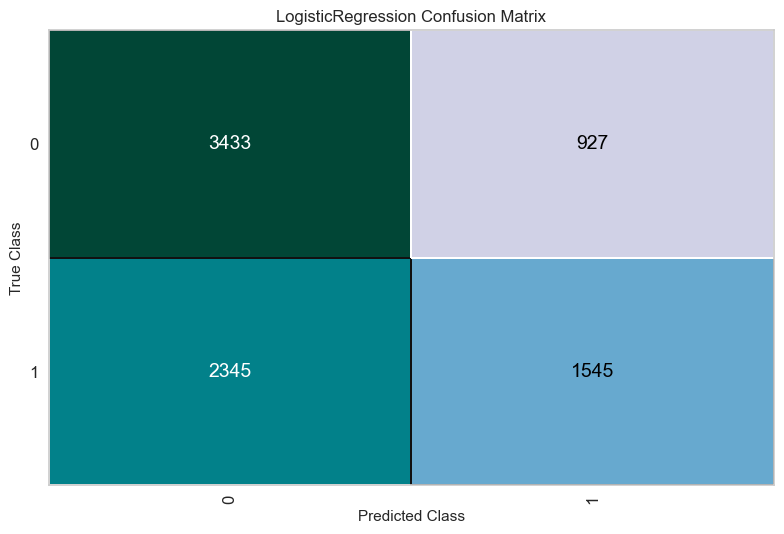

In [14]:
with warnings.catch_warnings():
    warnings.filterwarnings('ignore')
    cm = ConfusionMatrix(best_model,  classes=[0, 1], cmap='PuBuGn')
    cm.score(X_test, y_test)
    for label in cm.ax.texts:
        label.set_size(14)
    cm.show('../reports/figures/confusion matrix_before threshold moving.png'); 

- prediction threshold = 0.50 (default)
- average model accuracy = 0.604 ± 0.015
- recall score = 0.398

#### 5. Threshold Moving

- Logistic regression models output well-caliberated probabilities so there is no need to caliberate the probabilities predicted by the model.
- The hospital group want to focus follow-up calls and attention on those patients with a higher probability of readmission so it is ideal to adjust the default decision threshold of 0.50 to an optimal threshold that will make the model more accurate in prioritizing patients with a higher probability of readmission.

                Metric  Best Threshold  Precision  Recall  F-beta Score  Queue Rate
F0.5 (favor Precision)            0.47       0.62    0.50          0.59        0.38
         F1 (Balanced)            0.37       0.51    0.86          0.64        0.79
     F2 (favor Recall)            0.26       0.47    1.00          0.82        0.99


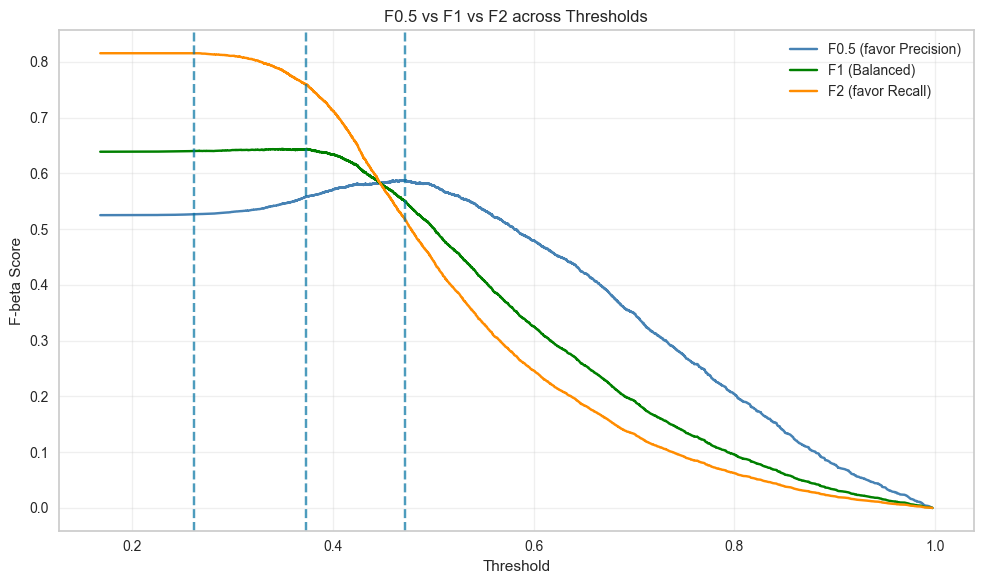

In [15]:
# ============================================
# 1. Get predicted probabilities
# ============================================
y_proba = best_model.predict_proba(X_train)[:, 1] 
y_true = y_train
# Using the training set is acceptable, especially if you don’t have a separate validation set.
# If you both tune the threshold and evaluate on the same data (especially the training set), the metrics will be optimistically biased.
# The test set should remain completely untouched until the final evaluation step.

# ============================================
# 2. Compute precision-recall curve
# ============================================
precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)

# ============================================
# 3. Helper function for F-beta
# ============================================
def calculate_fbeta(precisions, recalls, beta):
    return (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-10)

f05_scores = calculate_fbeta(precisions, recalls, beta=0.5)
f1_scores  = calculate_fbeta(precisions, recalls, beta=1.0)
f2_scores  = calculate_fbeta(precisions, recalls, beta=2.0)

# ============================================
# 4. Find best threshold + calculate metrics (including Queue Rate)
# ============================================
results = []

for name, scores, beta in [
    ("F0.5 (favor Precision)", f05_scores, 0.5),
    ("F1 (Balanced)",          f1_scores,  1.0),
    ("F2 (favor Recall)",      f2_scores,  2.0)
]:
    best_idx = np.argmax(scores)
    best_thresh = thresholds[best_idx]
    
    # Apply the threshold
    y_pred = (y_proba >= best_thresh).astype(int)
    
    # Queue Rate = % of patients flagged as high-risk
    queue_rate = y_pred.mean()
    
    results.append({
        "Metric": name,
        "Best Threshold": round(best_thresh, 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F-beta Score": round(fbeta_score(y_true, y_pred, beta=beta), 4),
        "Queue Rate": round(queue_rate, 4)          # ← New column
    })

# ============================================
# 5. Display results
# ============================================
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# ============================================
# 6. Visualization
# ============================================
plt.figure(figsize=(10, 6))

plt.plot(thresholds, f05_scores[:-1], label="F0.5 (favor Precision)", color="steelblue")
plt.plot(thresholds, f1_scores[:-1],  label="F1 (Balanced)",          color="green")
plt.plot(thresholds, f2_scores[:-1],  label="F2 (favor Recall)",      color="darkorange")

for res in results:
    plt.axvline(res["Best Threshold"], linestyle="--", alpha=0.7)

plt.xlabel("Threshold")
plt.ylabel("F-beta Score")
plt.title("F0.5 vs F1 vs F2 across Thresholds")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();

- To achieve high recall (F1 or F2), the model has to lower the threshold so much that it flags 87–99% of patients. This defeats the purpose of prioritization.
- The model does not separate high-risk and low-risk patients strongly enough for aggressive recall-oriented thresholds to be operationally valuable.
- F0.5 (threshold ≈ 0.47) is the only setting that remains practical. It flags about 38% of patients while still catching half of the actual readmissions, with better precision.

Given these numbers, I recommend:

1. Use the F0.5 threshold (≈ 0.47) as your primary operating point, or
2. Manually choose a threshold based on the hospital’s actual follow-up capacity (e.g., target a Queue Rate of 30–50% ie “flag the top 40% of patients”). Queue Rate tells you the operational load.

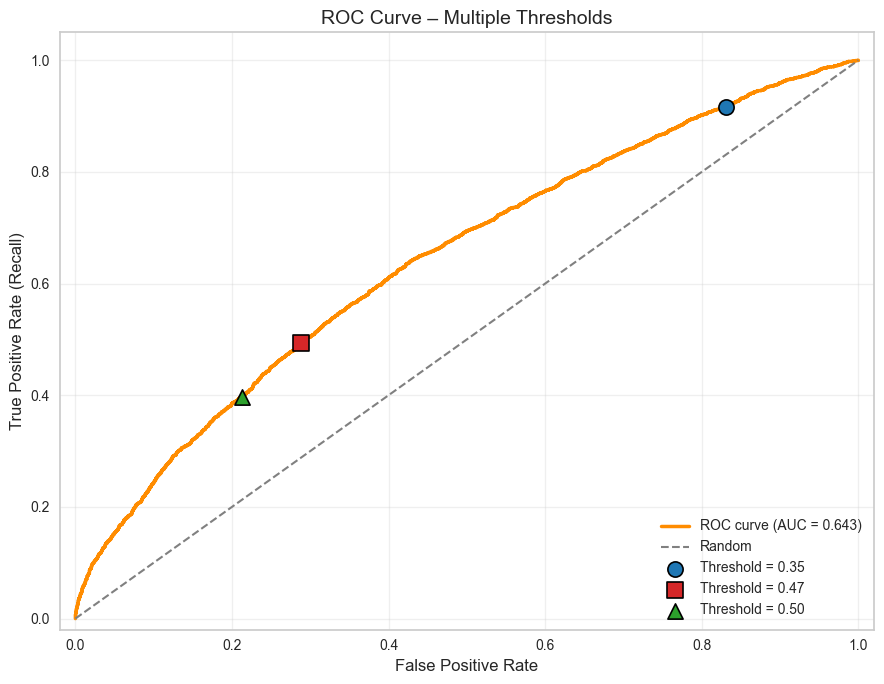

In [16]:
# ============================================
# Settings
# ============================================
THRESHOLDS_TO_COMPARE = [0.35, 0.47, 0.50]   # F1, F0.5, default
PRIMARY_THRESHOLD = 0.47                      # your preferred operating point

# Use test set for final evaluation
y_true = y_test
y_proba = best_model.predict_proba(X_test)[:, 1]

# ============================================
# 1. ROC Curve with multiple thresholds
# ============================================
fpr, tpr, roc_thresholds = roc_curve(y_true, y_proba)
roc_auc = roc_auc_score(y_true, y_proba)

plt.figure(figsize=(9, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random')

colors = ['#1f77b4', '#d62728', '#2ca02c']
markers = ['o', 's', '^']

for thresh, color, marker in zip(THRESHOLDS_TO_COMPARE, colors, markers):
    idx = np.argmin(np.abs(roc_thresholds - thresh))
    plt.scatter(fpr[idx], tpr[idx], color=color, s=120, marker=marker, zorder=5,
                edgecolors='black', linewidths=1.2,
                label=f'Threshold = {thresh:.2f}')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve – Multiple Thresholds', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();


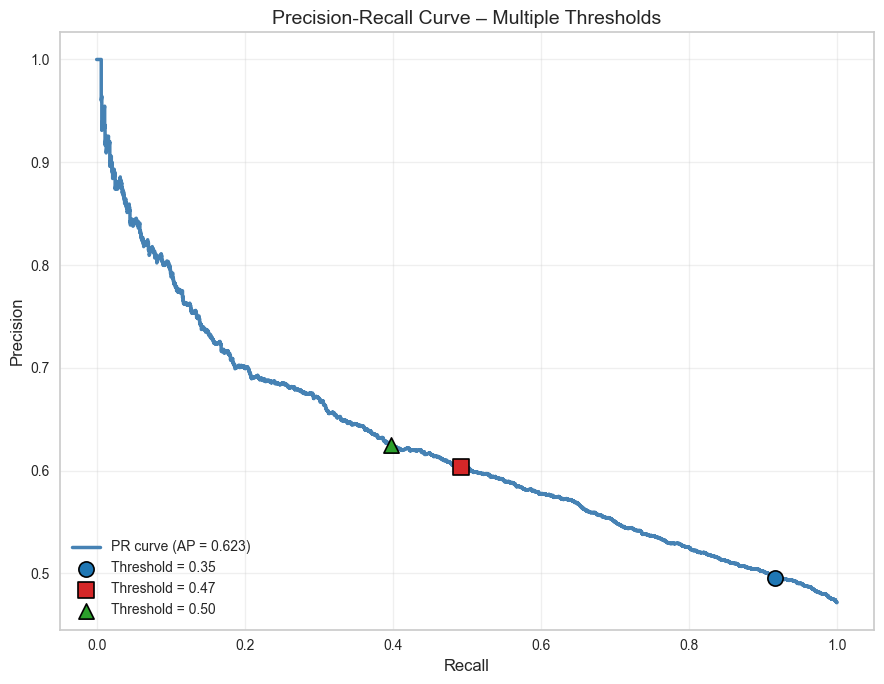

In [17]:

# ============================================
# 2. Precision-Recall Curve with multiple thresholds
# ============================================
precisions, recalls, pr_thresholds = precision_recall_curve(y_true, y_proba)
avg_precision = average_precision_score(y_true, y_proba)

plt.figure(figsize=(9, 7))
plt.plot(recalls, precisions, color='steelblue', lw=2.5,
         label=f'PR curve (AP = {avg_precision:.3f})')

for thresh, color, marker in zip(THRESHOLDS_TO_COMPARE, colors, markers):
    idx = np.argmin(np.abs(pr_thresholds - thresh))
    plt.scatter(recalls[idx], precisions[idx], color=color, s=120, marker=marker,
                zorder=5, edgecolors='black', linewidths=1.2,
                label=f'Threshold = {thresh:.2f}')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve – Multiple Thresholds', fontsize=14)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();


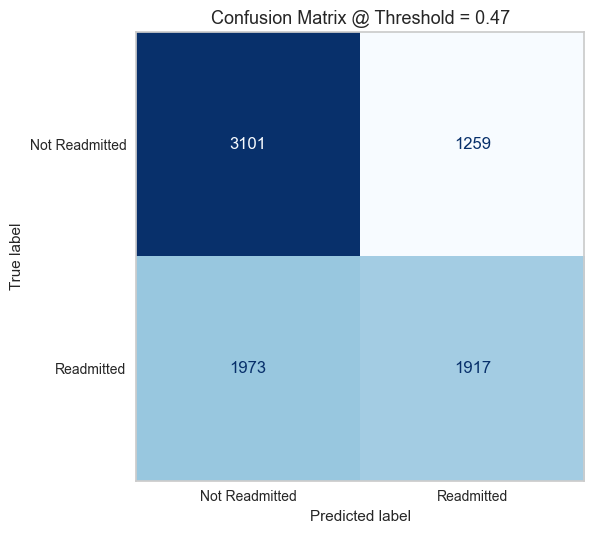

In [18]:
# ============================================
# 3. Confusion Matrix for the PRIMARY threshold
# ============================================
y_pred_primary = (y_proba >= PRIMARY_THRESHOLD).astype(int)
cm = confusion_matrix(y_true, y_pred_primary)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Readmitted', 'Readmitted']
)
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
plt.title(f'Confusion Matrix @ Threshold = {PRIMARY_THRESHOLD:.2f}', fontsize=13)
plt.grid(False)
plt.tight_layout()
plt.show();


In [19]:
# ============================================
# 4. Side-by-side performance table
# ============================================
results = []

for thresh in THRESHOLDS_TO_COMPARE:
    y_pred = (y_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    results.append({
        "Threshold": thresh,
        "Precision": round(precision_score(y_true, y_pred), 3),
        "Recall": round(recall_score(y_true, y_pred), 3),
        "F1": round(fbeta_score(y_true, y_pred, beta=1), 3),
        "F0.5": round(fbeta_score(y_true, y_pred, beta=0.5), 3),
        "F2": round(fbeta_score(y_true, y_pred, beta=2), 3),
        "Queue Rate": round((tp + fp) / len(y_true), 3),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("Performance Comparison Across Thresholds (Test Set)")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# Highlight the primary threshold
print(f"\n→ Primary recommended threshold: {PRIMARY_THRESHOLD}")
print(classification_report(y_true, y_pred_primary, 
                            target_names=['Not Readmitted', 'Readmitted']))


Performance Comparison Across Thresholds (Test Set)
 Threshold  Precision  Recall   F1  F0.5   F2  Queue Rate   TP   FP   FN   TN
      0.35       0.50    0.92 0.64  0.55 0.78        0.87 3564 3624  326  736
      0.47       0.60    0.49 0.54  0.58 0.51        0.39 1917 1259 1973 3101
      0.50       0.62    0.40 0.49  0.56 0.43        0.30 1545  927 2345 3433

→ Primary recommended threshold: 0.47
                precision    recall  f1-score   support

Not Readmitted       0.61      0.71      0.66      4360
    Readmitted       0.60      0.49      0.54      3890

      accuracy                           0.61      8250
     macro avg       0.61      0.60      0.60      8250
  weighted avg       0.61      0.61      0.60      8250



Output | Benefit
- ROC with 3 points | See how each threshold sits on the ranking curve
- PR with 3 points | Directly compare precision–recall tradeoffs at the exact operating points
- Confusion Matrix | Exact counts for the threshold you plan to deploy
- Comparison table | "Precision, Recall, F0.5 / F1 / F2, Queue Rate, and raw TP/FP/FN/TN side-by-side"

This makes it easy to justify the final threshold choice to stakeholders (e.g., “0.47 gives us 50% recall while only flagging ~38% of patients”).

### Post-Modeling
#### 1. Identifying Features Most Predictive of Hospital Readmissions

c:\Users\yvett\Documents\01 Yvette\DataProjects\personal\hospital-readmissions\.venv\lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


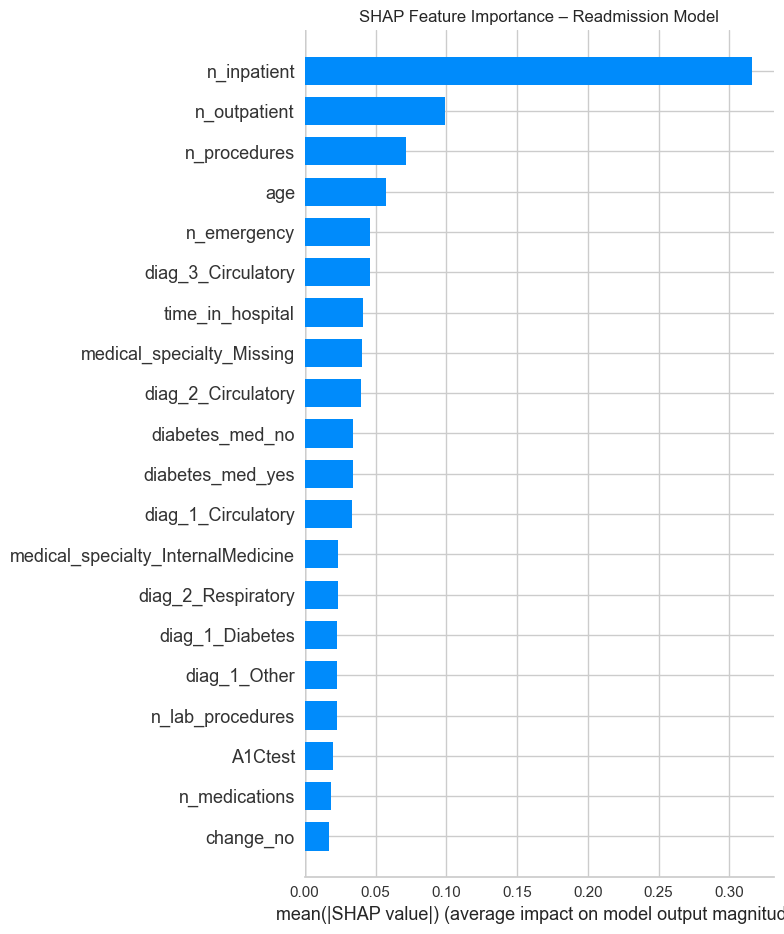

In [20]:
# ============================================
# 1. Prepare data for SHAP
# ============================================
# Get the preprocessor and the final estimator from your pipeline
preprocessor = preprocessor = best_model[:-1]  # everything except the model step
model = best_model.named_steps["m"]

# Transform the training (or test) data
X_transformed = preprocessor.transform(X_train)   # or X_test

# Get clean feature names (same logic you used)
feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split('__')[-1] for name in feature_names]

# ============================================
# 2. Create SHAP explainer (LinearExplainer is ideal for logistic regression)
# ============================================
explainer = shap.LinearExplainer(model, X_transformed, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_transformed)

# ============================================
# 3. Global feature importance (bar plot)
# ============================================
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_transformed, 
    feature_names=feature_names,
    plot_type="bar",          # mean |SHAP| importance
    show=False
)
plt.title("SHAP Feature Importance – Readmission Model")
plt.tight_layout()
plt.show();


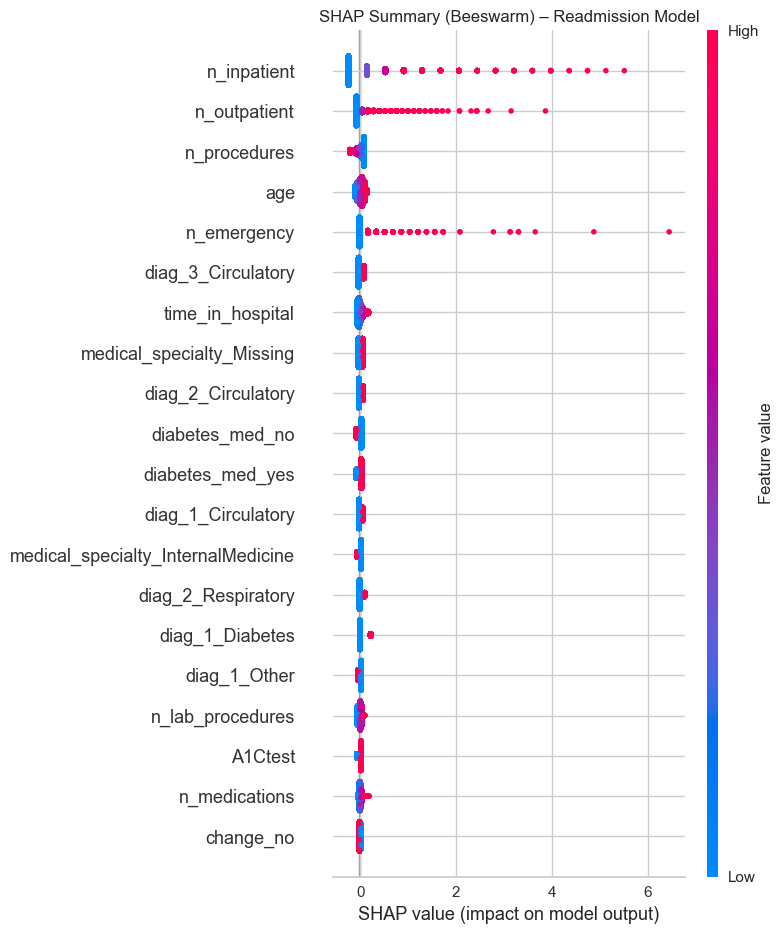

In [21]:
# ============================================
# 4. Detailed beeswarm plot (direction + magnitude)
# ============================================
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_transformed, 
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Summary (Beeswarm) – Readmission Model")
plt.tight_layout()
plt.show();

In [22]:
# ============================================
# 5. Top 3 most predictive features
# ============================================
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_|SHAP|": mean_abs_shap
}).sort_values("Mean_|SHAP|", ascending=False)

print("Top 3 most predictive features of readmission:")
print(importance_df.head(3).to_string(index=False))

Top 3 most predictive features of readmission:
     Feature  Mean_|SHAP|
 n_inpatient         0.32
n_outpatient         0.10
n_procedures         0.07


The **top 3 most predictive features** of readmission are:

- n_inpatient: High values (red) push the prediction strongly to the right → higher readmission risk. This is the dominant driver.
- n_outpatient: Higher outpatient visits also increase risk (red points to the right), but the effect is weaker and more spread out.
- n_procedures: Higher number of procedures tends to increase risk, though the impact is smaller.
- n_emergency: Visible red points far to the right show that a high number of emergency visits can substantially raise risk for some patients, even if its average importance is lower than the top 3.

Most other features (age, diagnoses, medications, etc.) cluster tightly around zero, meaning they have relatively small average impact in this model.

The model is largely driven by prior utilization:

Patients with more previous inpatient stays are at clearly elevated risk of being readmitted.
Outpatient and procedure volume add additional signal.

This aligns well with known patterns in hospital readmission risk and supports a practical prioritization strategy: focus follow-up resources on patients with high prior inpatient (and to a lesser extent outpatient/emergency) utilization.

#### 2. Decile and Gain/Lift Analysis

In [23]:
# ============================================
# 1. Prepare scored dataset (do not overwrite X_test permanently)
# ============================================
df_score = X_test.copy()
df_score["predicted_probability"] = best_model.predict_proba(X_test)[:, 1]
df_score["readmitted"] = y_test

# ============================================
# 2. Create deciles (automatically handles any test-set size)
# ============================================
df_score = df_score.sort_values("predicted_probability", ascending=False).reset_index(drop=True)

# pd.qcut creates equal-sized groups; rank ensures highest probability = Decile 1
df_score["decile"] = pd.qcut(
    df_score["predicted_probability"].rank(method="first", ascending=False),
    q=10,
    labels=[f"Decile_{i:02d}" for i in range(1, 11)]
)

# ============================================
# 3. Build summary table
# ============================================
summary = (
    df_score.groupby("decile", observed=True)
    .agg(
        **{
            "No of Patients": ("readmitted", "size"),
            "No of Patients Readmitted": ("readmitted", "sum"),
            "Minimum Probability": ("predicted_probability", "min"),
            "Maximum Probability": ("predicted_probability", "max"),
        }
    )
    .reset_index()
    .rename(columns={"decile": "Decile"})
)

summary["No of Patients Not Readmitted"] = (
    summary["No of Patients"] - summary["No of Patients Readmitted"]
)

# Cumulative & rate metrics
summary["Cumulative Patients"] = summary["No of Patients"].cumsum()
summary["Cumulative % of Patients"] = (
    summary["Cumulative Patients"] / summary["No of Patients"].sum() * 100
)

summary["Readmission Rate"] = (
    summary["No of Patients Readmitted"] / summary["No of Patients"] * 100
)

total_readmitted = summary["No of Patients Readmitted"].sum()
total_not_readmitted = summary["No of Patients Not Readmitted"].sum()

summary["% of Patients Readmitted"] = (
    summary["No of Patients Readmitted"] / total_readmitted * 100
)
summary["% of Patients Not Readmitted"] = (
    summary["No of Patients Not Readmitted"] / total_not_readmitted * 100
)

summary["Cumulative % of Patients Readmitted or Gain"] = (
    summary["% of Patients Readmitted"].cumsum()
)
summary["Cumulative % of Patients Not Readmitted"] = (
    summary["% of Patients Not Readmitted"].cumsum()
)

summary["KS Statistic"] = (
    summary["Cumulative % of Patients Readmitted or Gain"]
    - summary["Cumulative % of Patients Not Readmitted"]
)

summary["Lift"] = (
    summary["% of Patients Readmitted"] / summary["Cumulative % of Patients"]
)

# ============================================
# 4. Final column order
# ============================================
df_summary = summary[
    [
        "Decile",
        "No of Patients",
        "Cumulative Patients",
        "Cumulative % of Patients",
        "No of Patients Readmitted",
        "Readmission Rate",
        "% of Patients Readmitted",
        "% of Patients Not Readmitted",
        "Cumulative % of Patients Readmitted or Gain",
        "KS Statistic",
        "Lift",
        "Minimum Probability",
        "Maximum Probability",
    ]
]

# ============================================
# 5. Styled display (same highlighting logic)
# ============================================
def style_specific_cell(x):
    styles = pd.DataFrame("", index=x.index, columns=x.columns)
    # Highlight the Gain cell in Decile 5 (index 4) if desired
    if len(styles) > 4:
        styles.iloc[4, 8] = "background-color: #B1C5CD"
    return styles

styled = (
    df_summary.style
    .set_properties(**{"text-align": "center"})
    .format({
        "Readmission Rate": "{:.0f}%",
        "Cumulative % of Patients": "{:.0f}%",
        "% of Patients Readmitted": "{:.0f}%",
        "% of Patients Not Readmitted": "{:.0f}%",
        "Cumulative % of Patients Readmitted or Gain": "{:.0f}%",
        "KS Statistic": "{:.1f}",
        "Lift": "{:.2f}",
        "Minimum Probability": "{:.3f}",
        "Maximum Probability": "{:.3f}",
    })
    .highlight_max(subset=["KS Statistic"], color="#B1C5CD")
    .apply(style_specific_cell, axis=None)
)

styled

,Decile,No of Patients,Cumulative Patients,Cumulative % of Patients,No of Patients Readmitted,Readmission Rate,% of Patients Readmitted,% of Patients Not Readmitted,Cumulative % of Patients Readmitted or Gain,KS Statistic,Lift,Minimum Probability,Maximum Probability
0,Decile_01,825,825,10%,602,73%,15%,5%,15%,10.4,1.55,0.644,1.000
1,Decile_02,825,1650,20%,512,62%,13%,7%,29%,16.3,0.66,0.551,0.643
2,Decile_03,825,2475,30%,432,52%,11%,9%,40%,18.4,0.37,0.500,0.550
3,Decile_04,825,3300,40%,430,52%,11%,9%,51%,20.4,0.28,0.466,0.500
4,Decile_05,825,4125,50%,402,49%,10%,10%,61%,21.1,0.21,0.439,0.466
5,Decile_06,825,4950,60%,345,42%,9%,11%,70%,18.9,0.15,0.417,0.439
6,Decile_07,825,5775,70%,333,40%,9%,11%,79%,16.2,0.12,0.394,0.417
7,Decile_08,825,6600,80%,306,37%,8%,12%,86%,12.2,0.10,0.370,0.394
8,Decile_09,825,7425,90%,297,36%,8%,12%,94%,7.7,0.08,0.340,0.370
9,Decile_10,825,8250,100%,231,28%,6%,14%,100%,0.0,0.06,0.198,0.340


- Gain is the Cumulative % of Readmissions Captured
- The KS Statistic measures whether the model is able to distinguish between patients who will be readmitted or not. 

1. **Maximum KS = 1.8 at ~41% of patients**
This is the point of greatest separation between readmitted and non-readmitted patients. In practical terms, the model’s ranking power peaks around the top 4 deciles.

2. **At 50% of patients you capture 50% of readmissions**
This is essentially the same as random selection. The model is providing almost no lift once you go beyond the top ~40%.

3. **Overall discrimination is weak**
A maximum KS of only 1.8 (on a 0–100 scale) indicates very limited ability to separate high-risk from low-risk patients. Strong models typically show much higher peak KS values.

**Practical implication for the hospital**

- Focusing on the top 4 deciles (~40% of patients) is the most justifiable cutoff based on this table — it is where the KS peaks.
- Targeting the top 50% (as in the original project recommendation) captures about half the readmissions but does so with almost no advantage over random selection.
- The model has limited ranking power overall, so any prioritization strategy should be modest in its expectations and ideally combined with clinical judgment.

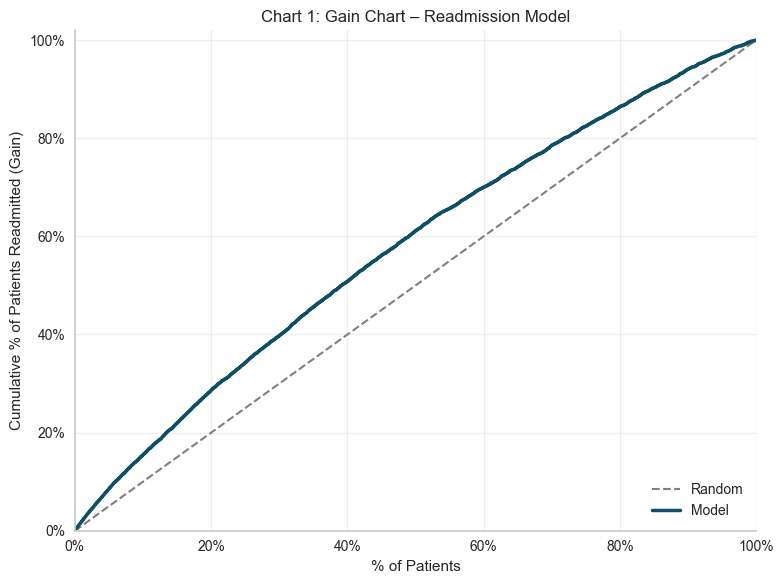

In [24]:
def plot_gain(y_real, y_proba, ax=None, color="#0e4f66", title="Gain Chart"):
    """
    Plot a cumulative gain chart.
    
    Parameters
    ----------
    y_real : array-like
        True binary labels (0/1)
    y_proba : array-like
        Predicted probabilities for the positive class
    ax : matplotlib axis, optional
    color : str
        Line color
    title : str
        Plot title
    """
    # Create and sort dataframe by predicted probability (highest first)
    df = (
        pd.DataFrame({"y_real": y_real, "y_proba": y_proba})
        .sort_values("y_proba", ascending=False)
        .reset_index(drop=True)
    )
    
    # Cumulative gain (vectorized)
    total_positives = df["y_real"].sum()
    df["gain"] = df["y_real"].cumsum() / total_positives
    df["pct_patients"] = np.arange(1, len(df) + 1) / len(df)
    
    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # Random baseline (diagonal)
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1.5, label="Random")
    
    # Gain curve
    ax.plot(df["pct_patients"], df["gain"], color=color, linewidth=2.5, label="Model")
    
    # Formatting
    ax.set_xlabel("% of Patients")
    ax.set_ylabel("Cumulative % of Patients Readmitted (Gain)")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x*100)}%"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y*100)}%"))
    
    ax.legend(loc="lower right")
    sns.despine()
    ax.grid(True, alpha=0.3)
    
    return ax

# Usage
plot_gain(
    y_real=y_test,                              # or X_test["readmitted"]
    y_proba=best_model.predict_proba(X_test)[:, 1],
    color="#0e4f66",
    title="Chart 1: Gain Chart – Readmission Model"
)
plt.tight_layout()
plt.show();

A **Gain Chart** shows how many of the actual readmissions you capture as you move down the ranked list of patients (from highest to lowest predicted risk).

- The **gray dashed line** = random selection (contacting X% of patients finds X% of readmissions).
- The **colored curve** = your model. The higher it rises above the diagonal early on, the better the model is at concentrating true readmissions at the top of the list.

**From your earlier decile results**, the gain curve is expected to stay close to the diagonal. This means:

- Ranking patients by the model’s probability gives only modest advantage over random selection.
- The biggest (still limited) benefit appears in the top ~40% of patients.
- After that, the curve tracks near the random line, confirming weak overall discrimination.

**Practical reading for stakeholders:**
“If we contact the top 40% of patients ranked by the model, we capture roughly 40% of all readmissions — only a small improvement over contacting a random 40% of patients. The model provides some prioritization value, but expectations should remain modest.”

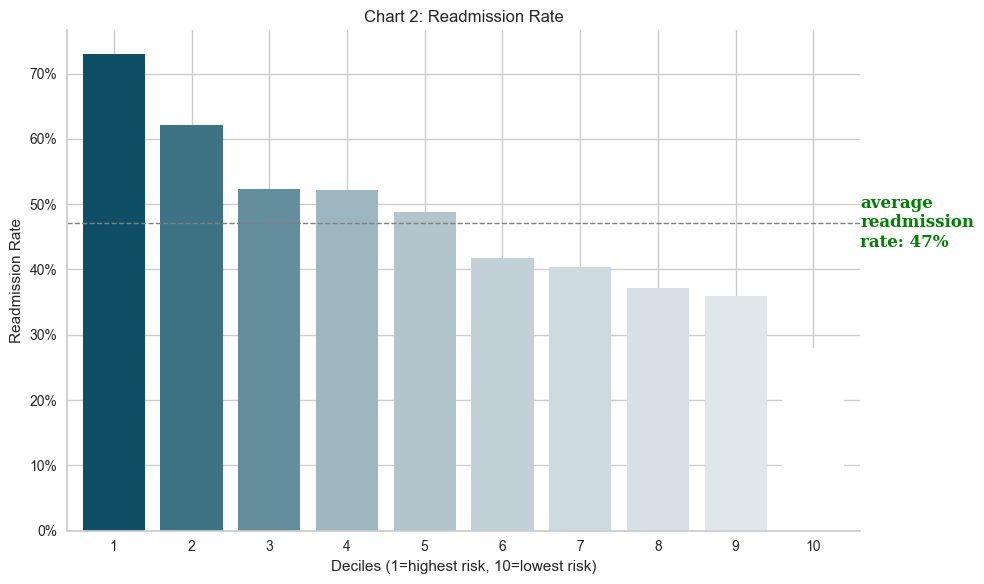

In [25]:
def plot_readmission_rate_by_decile(df_summary, title="Chart 2: Readmission Rate"):
    plot_df = df_summary.copy()
    plot_df["Decile_Num"] = plot_df["Decile"].str.extract(r"(\d+)").astype(int)
    plot_df = plot_df.sort_values("Decile_Num").reset_index(drop=True)
    
    avg_rate = plot_df["Readmission Rate"].mean()
    
    colors = [
        "#0e4f66", "#3E7285", "#658E9D", "#9DB7C1", "#B1C5CD",
        "#C1D1D7", "#CDDADF", "#D7E1E5", "#DFE7EA", "#FFFFFF"
    ]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Use 0-based positions for perfect alignment
    x_pos = np.arange(len(plot_df))  # 0, 1, 2, ..., 9
    
    bars = ax.bar(
        x_pos,
        plot_df["Readmission Rate"],
        color=colors,
        width=0.8,
        edgecolor="none"
    )
    
    # Average line
    ax.axhline(avg_rate, color="gray", linestyle="--", linewidth=1)
    
    # Labels
    ax.set_xlabel("Deciles (1=highest risk, 10=lowest risk)")
    ax.set_ylabel("Readmission Rate")
    ax.set_title(title)
    
    # Align tick labels under the center of each bar
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(i) for i in range(1, 11)])
    
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{int(y)}%")
    )
    ax.tick_params(axis="both", which="both", length=0)
    
    # Average annotation
    ax.text(
        9.6,
        avg_rate,
        f"average\nreadmission\nrate: {avg_rate:.0f}%",
        color="green",
        fontsize=12,
        fontweight="bold",
        fontfamily="serif",
        va="center",
        ha="left"
    )
    
    ax.set_xlim(-0.6, 9.6)
    sns.despine()
    plt.tight_layout()
    plt.show();
    
    return ax


# Usage
plot_readmission_rate_by_decile(df_summary);

**Interpretation**
This chart shows the **actual observed readmission rate** in each risk decile (Decile 1 = highest predicted risk, Decile 10 = lowest).

**What to look for:**

A good model produces a clear downward staircase: Decile 1 has the highest readmission rate, Decile 10 the lowest.
The steeper the drop from left to right, the better the model ranks patients.

The average readmission rate is about **47%.**
Because overall discrimination is modest, the bars will not show a dramatic decline across deciles.
Decile 1 should still be above average and Decile 10 below average, but the differences are relatively small.
This reinforces the earlier finding that the model provides only limited prioritization value.

**Stakeholder reading:**
“Patients in the highest-risk decile are more likely to be readmitted than those in the lowest-risk decile, but the difference is not large. The model can help focus attention on higher-risk groups, yet it should not be treated as a highly precise ranking tool.”

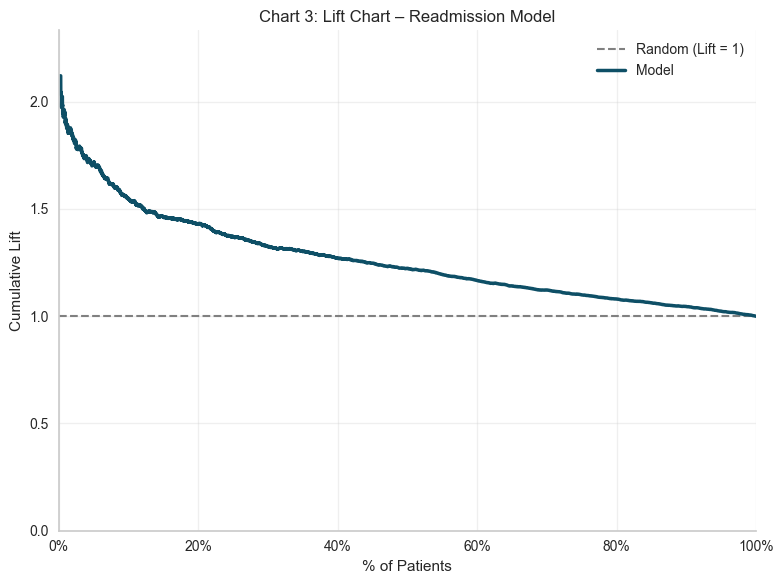

In [26]:
def plot_lift(y_real, y_proba, ax=None, color="#0e4f66", title="Chart 3: Lift Chart"):
    """
    Plot a cumulative lift curve.
    
    Lift = (readmission rate in the top X% of patients)
           / (overall readmission rate)
    """
    # Prepare and sort data (highest predicted risk first)
    df = (
        pd.DataFrame({"y_real": y_real, "y_proba": y_proba})
        .sort_values("y_proba", ascending=False)
        .reset_index(drop=True)
    )
    
    n = len(df)
    overall_rate = df["y_real"].mean()
    
    # Vectorized cumulative lift
    df["cum_positives"] = df["y_real"].cumsum()
    df["cum_patients"] = np.arange(1, n + 1)
    df["pct_patients"] = df["cum_patients"] / n
    df["lift"] = (df["cum_positives"] / df["cum_patients"]) / overall_rate
    
    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # Baseline (lift = 1)
    ax.axhline(1, color="gray", linestyle="--", linewidth=1.5, label="Random (Lift = 1)")
    
    # Lift curve
    ax.plot(df["pct_patients"], df["lift"], color=color, linewidth=2.5, label="Model")
    
    # Formatting
    ax.set_xlabel("% of Patients")
    ax.set_ylabel("Cumulative Lift")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(df["lift"].max() * 1.1, 1.5))
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x*100)}%"))
    ax.tick_params(axis="both", which="both", length=0)
    
    ax.legend(loc="upper right")
    sns.despine()
    ax.grid(True, alpha=0.3)
    
    return ax


# Usage
plot_lift(
    y_real=y_test,
    y_proba=best_model.predict_proba(X_test)[:, 1],
    color="#0e4f66",
    title="Chart 3: Lift Chart – Readmission Model"
)
plt.tight_layout()
plt.show();

**Interpretation**
**Lift** measures how much better the model is than random selection at a given outreach depth.

- **Lift = 1** → same as random
- **Lift = 2** → twice as many readmissions captured as random selection of the same number of patients
- **Lift = 1.5** → 50% better than random

**How to read the curve:**

- The far left (top 1–10% of patients) usually shows the highest lift.
- As you include more patients, lift declines toward 1.

- Expect relatively modest lift, even in the top deciles.
- A lift of ~1.3–1.6 in the top 10–20% would indicate some prioritization value.
- By the time you reach 40–50% of patients, lift will likely be close to 1.0, confirming limited ranking power.

**Stakeholder reading:**
“If we contact the highest-risk patients first, how many more readmissions do we find compared with contacting the same number of patients at random? The lift chart shows that advantage is modest and declines quickly as we expand outreach.”

# Export

In [27]:
# Final model
# joblib.dump(best_model_opt_0_5, '../models/hospital_readmission_model.joblib')